In [1]:
import numpy as np
import pandas as pd
import soundfile as sf
import ffmpeg
import matplotlib.pyplot as plt
import time
from pyannote.audio import Pipeline
import torch
from os import listdir
from os.path import isfile, join
import pickle
from itertools import combinations
import sklearn
from sklearn.neighbors import KernelDensity

## Data Process

In [2]:
class Pydia:
    def __init__(self, conference, session, num_speaker):
        self.conference = conference
        self.session = session
        self.num_speaker = num_speaker
        
        self.PyDiaPath = "diarization_result/" + conference + "/"+ session
        self.diarizations = self.get_dia()
        
        
    def get_dia(self):
        onlyfiles = [join(self.PyDiaPath,f) for f in listdir(self.PyDiaPath) if isfile(join(self.PyDiaPath, f))]
        diarizations = []
        for i in range(len(onlyfiles)):
            outputName = onlyfiles[i]
            with open(outputName, "rb") as fp:
                tmp = pickle.load(fp)
            diarizations.append(tmp)
        return diarizations
    
    # TODO: Align the diarizations, can be done manually
    def offset(self):
        pass
    
    def find_intro(self, start=0, end=6000, window=400, threshold=5, given_idx=-1):
        result = []
        allspeaker, total_time, min_idx, idx, speakers, d_list = self.select_speaker(start,end,given_idx=given_idx)
        flat = self.combine_speaker(allspeaker)
        for i in range(len(flat)):
            j = i
            tmp_end_time = flat[i][0] + window 
            tmp_check = [0 for k in range(len(allspeaker))]
            tmp_speaking_time = [0 for k in range(len(allspeaker))]
            prev_speaker = flat[i][2]
            flag = 0
            while j<len(flat) and flat[j][1] < tmp_end_time:
                tmp_speaker = flat[j][2]
                tmp_check[tmp_speaker] = 1
                tmp_speaking_time[tmp_speaker] = tmp_speaking_time[tmp_speaker] + flat[j][1] - flat[j][0]
                j = j+1
                prev_speaker = tmp_speaker
                if self.check_intro(tmp_check, tmp_speaking_time, threshold=threshold):
                    result.append([flat[i][0], flat[j][1]])
                    flag = 1
                    break
            #if flag=1, we already found the intro. We need to complete the intro of last speaker.
            if flag == 1:
                while j<len(flat) and flat[j][2] == prev_speaker:
                    j = j+1
                result[-1][1] = flat[j-1][1]

        return result, min_idx, flat, d_list, allspeaker, total_time, speakers

    
    ## Functions used for find_intro (Start) 
    # ----------------------------------------------------------------------------------------- #
    def check_intro(self,tmp_check,tmp_speaking_time,threshold=5):
        if all(tmp_check):
            if min(tmp_speaking_time) > threshold:
                return True
        return False
    
    def select_speaker(self,start,end,given_idx=-1):
        speakers, times, d_list = [], [], []
        min_num = 2*self.num_speaker
        min_idx = -1
        for i in range(len(self.diarizations)):
            speaker, time, d = self.sort_speaker(self.diarizations[i],start_time=start,end_time=end)
            speakers.append(speaker)
            times.append(time)
            d_list.append(d)
            if len(time) < min_num:
                min_num, min_idx = len(time), i
        if given_idx != -1:
            #print(self.onlyfiles[given_idx])
            return speakers[given_idx], times[given_idx], given_idx, [], speakers, d_list[given_idx][:num_speaker]
        if min_num == self.num_speaker:
            #print(self.onlyfiles[min_idx])
            return speakers[min_idx], times[min_idx], min_idx, [], speakers, d_list[min_idx][:num_speaker]

        #vote records the most likely
        vote = [0 for i in range(min_num)]
        for i in range(len(speakers)):
            if i != min_idx:
                idx = self.check_ghost(speakers[min_idx],speakers[i],times[min_idx],times[i],self.num_speaker)
                for k in range(len(idx)):
                    vote[idx[k]] += 1
        idx = np.argpartition(vote, -min_num + self.num_speaker) 
        idx = idx[-min_num + self.num_speaker:]
            
        speaker = [i for j, i in enumerate(speakers[min_idx]) if j not in idx]
        time = [i for j, i in enumerate(times[min_idx]) if j not in idx]
        
        #print(self.onlyfiles[min_idx])
        return speaker, time, min_idx, idx, speakers, d_list[min_idx][:num_speaker]
    
    def check_ghost(self,r1, r2, t1, t2, num_speaker):
        num_speaker1 = len(t1)
        num_speaker2 = len(t2)
        speaker_score = np.zeros((num_speaker1,num_speaker2))
        for i in range(num_speaker1):
            for j in range(num_speaker2):
                if t1[i] != 0 and t2[j] != 0: #check whether the speaking time is 0. Skip if speaking time is 0.
                    sum_overlap, sum_1, sum_2 = self.compare_interval(r1[i],r2[j])
                    E1 = sum_overlap/sum_1
                    E2 = sum_overlap/sum_2
                    speaker_score[i,j] = E1+E2
        best_match = speaker_score.max(axis=1)
        idx = np.argpartition(best_match, num_speaker1 - num_speaker)
        return idx[:num_speaker1 - num_speaker].astype(int)
    
    def sort_speaker(self,diarization, start_time=0, end_time=6000):
        time_window = 2
        allspeaker, total_time = self.pyannote_process(self.num_speaker, diarization, start_time, end_time, time_window)
        speaker = [x for _, x in sorted(zip(total_time, allspeaker),reverse=True)]
        time = sorted(total_time,reverse=True)
        d = sorted(range(len(total_time)), key=lambda k: total_time[k], reverse=True)
        return speaker, time, d
    
    def pyannote_process(self,num_speaker, diarization, start, end, threshold):
        intervals = [[[0,0]] for i in range(num_speaker)]
        total_times = [0 for i in range(num_speaker)]
        #print(intervals)
        for turn, _, speaker in diarization.itertracks(yield_label=True):
            temp_speaker = int(speaker.split("_")[-1])
            while temp_speaker >= len(intervals):
                intervals.append([[0,0]])
                total_times.append(0)
            #print(temp_speaker)
            if turn.start > start and turn.end < end:
                if turn.end - turn.start >= threshold:
                    intervals[temp_speaker].append([turn.start, turn.end])
                    total_times[temp_speaker] += turn.end - turn.start

        for j in range(num_speaker):
            intervals[j] = self.smooth(intervals[j], threshold)
        return intervals, total_times

    def smooth(self, interval, threshold):
        result = [interval[0]]
        prev_end = interval[0][1]
        for i in range(1,len(interval)):
            if interval[i][0] - prev_end < threshold:
                result[-1][1] = interval[i][1]
            else:
                result.append(interval[i])
            prev_end = interval[i][1]
        return result

    def combine_speaker(self, allspeaker):
        #allspeaker = allspeaker[:self.num_speaker]
        flat = []
        for i in range(len(allspeaker)):
            for segment in allspeaker[i]:
                segment_start, segment_end = segment[0], segment[1]
                if segment_end - segment_start > 0:
                    flat.append([segment_start, segment_end, i])
        flat.sort(key=lambda x: x[0])
        return flat
    
    # ----------------------------------------------------------------------------------------- #
    ##Functions used for find_intro (End)

    def match_recording(self,r1, r2, t1, t2, threshold=0.2):
        num_speaker1 = len(t1)
        num_speaker2 = len(t2)
        d = {}
        for i in range(num_speaker1):
            for j in range(num_speaker2):
                if t1[i] != 0 and t2[j] != 0: #check whether the speakering time is 0. Skip if speaking time is 0.
                    sum_overlap, sum_1, sum_2 = self.compare_interval(r1[i],r2[j])
                    E1 = 1 - sum_overlap/sum_1
                    E2 = 1 - sum_overlap/sum_2
                    if E1 + E2 < threshold:
                        d[i] = j
                        break
        return d            


    def compare_interval(self,s1,s2):
        i = 0
        j = 0
        sum_overlap = 0
        sum_i = 0
        sum_j = 0
        for k in range(len(s1)):
            sum_i += s1[k][1] - s1[k][0]
        for k in range(len(s2)):
            sum_j += s2[k][1] - s2[k][0]

        #compute overlapping intervals
        while i < len(s1) and j < len(s2):
            temp1 = s1[i]
            temp2 = s2[j]
            overlap = 0
            if temp1[0] <= temp2[0]:
                if temp1[1] <= temp2[0]: #case 5
                    i += 1
                    #print(5)
                else:
                    if temp1[1] <= temp2[1]: #case 1
                        i += 1
                        overlap = temp1[1] - temp2[0]
                        #print(1)
                    else: #case 2
                        j += 1
                        overlap = temp2[1] - temp2[0]
                        #print(2)
            else:
                if temp1[1] <= temp2[1]: #case 3
                    i += 1
                    overlap = temp1[1] - temp1[0]
                    #print(3)
                else: #case 4
                    if temp1[0] > temp2[1]: #case 6
                        j += 1
                        #print(6)
                    else: #case 4
                        j += 1
                        overlap = temp2[1] - temp1[0]
                        #print(4)
            #print(overlap,i,j)
            sum_overlap += overlap

        return sum_overlap, sum_i, sum_j 


    def select_Intro(self, start=0,end=6000,idx=0,window=400,given_idx=-1):
        intros, min_idx, flat, d_list, allspeaker, total_time, speakers = self.find_intro(start=start,end=end,window=window,given_idx=given_idx)
        if len(intros) > idx:
            intro = intros[idx]
            tmp_diarization = self.diarizations[min_idx]
            flat_2darray = np.array(flat)
            flat_2darray = flat_2darray[flat_2darray[:,0]>=intro[0]]
            flat_2darray = flat_2darray[flat_2darray[:,1]<=intro[1]]
            start_times = flat_2darray[:,0] - flat_2darray[0,0]
            end_times = flat_2darray[:,1] - flat_2darray[0,0]
            labels = flat_2darray[:,2].astype('int')
            df = pd.DataFrame()
            df['start'] = start_times
            df['end'] = end_times
            df['labels'] = labels
            df.to_excel("Intro/"+self.conference+"/"+self.session+".xlsx") 
        else:
            intro = []

        return intros, intro, min_idx, d_list, flat, allspeaker, total_time, speakers

In [3]:
class Confidence:
    def __init__(self, conference, session, num_speaker):
        self.conference = conference
        self.session = session
        self.num_speaker = num_speaker

        self.PyDiaPath = "diarization_result/" + conference + "/"+ session
        self.AmpDiaPath = "amplitude_result/" + conference + "/"+ "amplitude_"+session+".csv"
        self.AmpConfPath = "amplitude_confidence/"+conference + "/" + "ampconf_"+session+".csv"
        self.diarizations = self.get_dia() #diarizations from Pyannote

    def get_dia(self):
        onlyfiles = [join(self.PyDiaPath,f) for f in listdir(self.PyDiaPath) if isfile(join(self.PyDiaPath, f))]
        diarizations = []
        for i in range(len(onlyfiles)):
            outputName = onlyfiles[i]
            with open(outputName, "rb") as fp:
                tmp = pickle.load(fp)
            diarizations.append(tmp)
        return diarizations

    def Pyconf(self, allspeaker, total_time):
        recording_list = []
        total_times_list = []
        for i in range(len(self.diarizations)):
            tmp_speaker, tmp_total_times = self.pyannote_process(self.num_speaker, self.diarizations[i], 0, 6000, 2)
            recording_list.append(tmp_speaker)
            total_times_list.append(tmp_total_times)
        confidence_matrix, dmatrix = self.create_confidence_by_voting(recording_list, total_times_list, allspeaker, total_time)
        confidence = confidence_matrix.sum(axis=0)
        r1_flat = self.combine_speaker(allspeaker)
        return confidence, confidence_matrix, r1_flat

    ## Functions used for Pyconf (START)
    # ----------------------------------------------------------------------------------------- #
    def pyannote_process(self,num_speaker, diarization, start, end, threshold):
        intervals = [[[0,0]] for i in range(num_speaker)]
        total_times = [0 for i in range(num_speaker)]
        #print(intervals)
        for turn, _, speaker in diarization.itertracks(yield_label=True):
            temp_speaker = int(speaker.split("_")[-1])
            while temp_speaker >= len(intervals):
                intervals.append([[0,0]])
                total_times.append(0)
            #print(temp_speaker)
            if turn.start > start and turn.end < end:
                if turn.end - turn.start >= threshold:
                    intervals[temp_speaker].append([turn.start, turn.end])
                    total_times[temp_speaker] += turn.end - turn.start

        for j in range(num_speaker):
            intervals[j] = self.smooth(intervals[j], threshold)
        return intervals, total_times

    def smooth(self,interval, threshold):
        result = [interval[0]]
        prev_end = interval[0][1]
        for i in range(1,len(interval)):
            if interval[i][0] - prev_end < threshold:
                result[-1][1] = interval[i][1]
            else:
                result.append(interval[i])
            prev_end = interval[i][1]
        return result

    def create_confidence_by_voting(self,recording_list, total_times_list, allspeaker, total_time):    
        #Step 1
        num_recordings = len(recording_list)
        labels_match_diclist = []
        r1, t1 = allspeaker, total_time
        for i in range(num_recordings):
            r2, t2 = recording_list[i], total_times_list[i]
            tmp_d = self.match_recording(r1,r2,t1,t2,threshold=1)
            labels_match_diclist.append(tmp_d)


        #Step 2
        vote_matrix = []
        for i in range(num_recordings):
            r2, d = recording_list[i], labels_match_diclist[i]
            tmp_pairvote = self.check_match(r1,r2,d)
            vote_matrix.append(tmp_pairvote)

        return np.array(vote_matrix),labels_match_diclist

    def match_recording(self,r1, r2, t1, t2, threshold=0.2):
        num_speaker1 = len(t1)
        num_speaker2 = len(t2)
        d = {}
        for i in range(num_speaker1):
            for j in range(num_speaker2):
                if t1[i] != 0 and t2[j] != 0: #check whether the speakering time is 0. Skip if speaking time is 0.
                    sum_overlap, sum_1, sum_2 = self.compare_interval(r1[i],r2[j])
                    E1 = 1 - sum_overlap/sum_1
                    E2 = 1 - sum_overlap/sum_2
                    if E1 + E2 < threshold:
                        d[i] = j
                        break
        return d   


    #r1 is the reference recording which all other recordings compared to
    def check_match(self,r1,r2,d,threshold=0.2):
        #Step 1: flatten the reference recording list
        r1_flat = []
        for i in range(len(r1)):
            for segment in r1[i]:
                segment_start, segment_end = segment[0], segment[1]
                if segment_end - segment_start > 0:
                    r1_flat.append([segment_start, segment_end, i])
        r1_flat.sort(key=lambda x: x[0])


        #Step 2: check whether a segment has multiple labels
        result = [0 for i in range(len(r1_flat))] #list of 0s or 1s
        for i in range(len(r1_flat)):
            segment = r1_flat[i]
            r1_start, r1_end, r1_label = segment[0], segment[1], segment[2]
            if r1_label in d:
                r2_label = d[r1_label]
                overlap, t1, t2 = self.compare_interval([segment],r2[r2_label])
                E1 = 1 - overlap/t1
                if E1 < threshold:
                    result[i] = 1
        return result  

    def compare_interval(self,s1,s2):
        i = 0
        j = 0
        sum_overlap = 0
        sum_i = 0
        sum_j = 0
        for k in range(len(s1)):
            sum_i += s1[k][1] - s1[k][0]
        for k in range(len(s2)):
            sum_j += s2[k][1] - s2[k][0]

        #compute overlapping intervals
        while i < len(s1) and j < len(s2):
            temp1 = s1[i]
            temp2 = s2[j]
            overlap = 0
            if temp1[0] <= temp2[0]:
                if temp1[1] <= temp2[0]: #case 5
                    i += 1
                    #print(5)
                else:
                    if temp1[1] <= temp2[1]: #case 1
                        i += 1
                        overlap = temp1[1] - temp2[0]
                        #print(1)
                    else: #case 2
                        j += 1
                        overlap = temp2[1] - temp2[0]
                        #print(2)
            else:
                if temp1[1] <= temp2[1]: #case 3
                    i += 1
                    overlap = temp1[1] - temp1[0]
                    #print(3)
                else: #case 4
                    if temp1[0] > temp2[1]: #case 6
                        j += 1
                        #print(6)
                    else: #case 4
                        j += 1
                        overlap = temp2[1] - temp1[0]
                        #print(4)
            #print(overlap,i,j)
            sum_overlap += overlap

        return sum_overlap, sum_i, sum_j 

    def combine_speaker(self, allspeaker):
        #allspeaker = allspeaker[:self.num_speaker]
        flat = []
        for i in range(len(allspeaker)):
            for segment in allspeaker[i]:
                segment_start, segment_end = segment[0], segment[1]
                if segment_end - segment_start > 0:
                    flat.append([segment_start, segment_end, i])
        flat.sort(key=lambda x: x[0])
        return flat

    # ----------------------------------------------------------------------------------------- #
    ## Functions used for Pyconf (END)

    def visualize(self, r1_flat, confidence, rangeX=[0,300]):
        fig, ax1 = plt.subplots()
        color = 'tab:blue'
        for j in range(len(r1_flat)):
            ax1.hlines(y=r1_flat[j][2], xmin=r1_flat[j][0], xmax=r1_flat[j][1], linewidth=2, color=color)
        ax1.set_xlabel('time (s)')
        ax1.set_ylabel('speaker', color=color)
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.set_xlim(rangeX)

        color = 'tab:green'
        ax2 = ax1.twinx()
        ax2.set_ylabel('confidence', color=color)
        for j in range(len(r1_flat)):
            ax2.fill_betweenx([0,(confidence[j]+1)/self.num_speaker], r1_flat[j][0], r1_flat[j][1], color=color, alpha=0.1)

        ax2.tick_params(axis='y', labelcolor=color)

        plt.grid()
        plt.show()

    def visualize_amplitude(self, diarization, confidence_curve, time, d_list, rangeX=[0,300], ENDTIME=4000, confidence_curve2=None, smooth=False, threshold=16*2):
        Amp_Intro, Amp_Intro_times = self.amplitude_process(self.num_speaker, diarization, 0, ENDTIME, 2)
        #print(Amp_Intro_MZT3_2_4)
        if smooth:
            confidence_curve = self.moving_average(np.array(confidence_curve), threshold)
            time = self.moving_average(np.array(time), threshold)
            if len(confidence_curve2) > 0:
                confidence_curve2 = self.moving_average(np.array(confidence_curve2), threshold)
        fig, ax1 = plt.subplots()
        color = 'tab:blue'
        for j in range(self.num_speaker):
            tmp_speaker = Amp_Intro[j]
            for i in range(len(tmp_speaker)):
                ax1.hlines(y=d_list[j], xmin=tmp_speaker[i][0], xmax=tmp_speaker[i][1], linewidth=2, color=color)
        ax1.set_xlabel('time (s)')
        ax1.set_ylabel('speaker', color=color)
        ax1.tick_params(axis='y', labelcolor=color)
        ax1.set_xlim(rangeX)

        color = 'tab:green'
        ax2 = ax1.twinx()
        ax2.set_ylabel('confidence', color=color)
        ax2.fill_between(time, confidence_curve, color=color, alpha=0.1)

        if len(confidence_curve2) > 0:
            ax2.fill_between(time, confidence_curve2, color='tab:red', alpha=0.1)

        ax2.tick_params(axis='y', labelcolor=color)

        plt.grid()
        plt.show()

    ## Functions used for visualize_amplitude (START)
    # ----------------------------------------------------------------------------------------- #	    
    def moving_average(self,x, w):
        return np.convolve(x, np.ones(w), 'valid') / w

    def amplitude_process(self,num_speaker, diarization, start, end, threshold):
        intervals = [[[0,0]] for i in range(num_speaker)]
        total_times = [0 for i in range(num_speaker)]

        for i in range(len(diarization)):
            # -1 for the index of temp_speaker because in matlab for indexing the speaker starting from 1
            turn_start, turn_end, temp_speaker = diarization[i][0], diarization[i][1], int(diarization[i][2])       

            if turn_start > start and turn_end < end:
                if turn_end - turn_start >= threshold:
                    intervals[temp_speaker].append([turn_start, turn_end])
                    total_times[temp_speaker] += turn_end - turn_start

        for j in range(num_speaker):
            intervals[j] = self.smooth(intervals[j], threshold)
        return intervals, total_times

    # ----------------------------------------------------------------------------------------- #
    ## Functions used for visualize_amplitude (END)


    def ampconf(self,d_list,rangeX=[350,400]):
        df_amplitude = pd.read_csv(self.AmpDiaPath, header=None)
        df_amplitude.rename(columns={0: 'start', 1: 'end', 2: 'label'}, inplace=True)

        df_ampconf = pd.read_csv(self.AmpConfPath, header=None)
        df_ampconf.rename(columns={0: 'conf_local', 1: 'conf_global', 2: 'conf_multi', 3: 'time'}, inplace=True)
        ampconf = df_ampconf.to_numpy()

        time = ampconf[:,3]
        confidence_curve = ampconf[:,0]/max(ampconf[:,0])
        confidence_curve2 = ampconf[:,2]/max(ampconf[:,2])

        self.visualize_amplitude(df_amplitude.to_numpy(), confidence_curve, time, d_list, rangeX=rangeX, confidence_curve2=confidence_curve2,smooth=True,threshold=16*1)

        return df_ampconf, df_amplitude

In [4]:
from copy import deepcopy
class CombineAudio:
    def __init__(self, conference, session):
        self.conference = conference
        self.session = session
        
        self.PyDiaPath = "diarization_result/" + conference + "/"+ session
        self.diarizations = self.get_dia()
        self.intervals = self.pyannote_process(self.diarizations, 0, 6000, 1)
        
        
    def get_dia(self):
        onlyfiles = [join(self.PyDiaPath,f) for f in listdir(self.PyDiaPath) if isfile(join(self.PyDiaPath, f))]
        diarizations = []
        for i in range(len(onlyfiles)):
            outputName = onlyfiles[i]
            with open(outputName, "rb") as fp:
                tmp = pickle.load(fp)
            diarizations.append(tmp)
        return diarizations
    
    def pyannote_process(self, diarizations, start, end, threshold):
        intervals = []
        for i in range(len(diarizations)):
            diarization = diarizations[i]
            interval = []
            #print(intervals)
            for turn, _, speaker in diarization.itertracks(yield_label=True):
                temp_speaker = int(speaker.split("_")[-1])
                if turn.start > start and turn.end < end:
                    if turn.end - turn.start >= threshold:
                        interval.append([turn.start, turn.end])
            intervals.append(interval)
        return intervals
     
    # Only add missing intervals
    def process_intervals_v1(self, threshold):
        intervals = self.intervals
        result = deepcopy(intervals[0])
        
        for i in range(len(intervals)):
            tmp_silence = self.find_silence(result, threshold)
            tmp_interval = intervals[i]
            ct = 0
            j=0
            while j < len(tmp_silence) and ct<len(tmp_interval):
                start, end = tmp_silence[j][0], tmp_silence[j][1]
                tmp_seg = tmp_interval[ct]
                
                if tmp_seg[1] <= start: #case 5
                    ct = ct + 1

                elif tmp_seg[0] >= end:  #case 6: do nothing
                    j = j+1

                elif tmp_seg[0]>=start and tmp_seg[1]>=end: #case 1: 
                    result.append([tmp_seg[0],end])                    
                    j = j+1

                elif tmp_seg[0]<=start and tmp_seg[1]<=end: #case 2:
                    result.append([start,tmp_seg[1]])
                    ct = ct + 1

                elif tmp_seg[0]<=start and tmp_seg[1]>=end: #case 3:
                    result.append([start,end])
                    j = j+1

                elif tmp_seg[0]>=start and tmp_seg[1]<=end: #case 4:
                    result.append([tmp_seg[0],tmp_seg[1]])
                    ct = ct + 1
                    
            result = sorted(result,key=lambda x: (x[0],x[1]))
                    
        new_result = set()
        for seg in result:
            start, end = round(seg[0], 2), round(seg[1],2)
            new_result.add(start)
            new_result.add(end)
                        
        return sorted(new_result)

        
    def find_silence(self, result, threshold):
        silence = []        
        for i in range(len(result)-1):
            start, end = result[i][1], result[i+1][0]
            if end-start > threshold:
                silence.append([start, end])
        return silence
        
    # Find all segments: Does not work very well. Create a lot of small segments.
    def process_intervals_v2(self, threshold):
        intervals = self.intervals
        result = deepcopy(intervals[0])
        for i in range(len(intervals)):
            tmp_interval = intervals[i]
            ct = 0
            j=0
            while j < len(result) and ct < len(tmp_interval):
                start, end = result[j][0], result[j][1]
                tmp_seg = tmp_interval[ct]
                #remove small difference
                if abs(tmp_seg[0]-start)<threshold:
                    tmp_seg[0] = start
                if abs(tmp_seg[1]-end)<threshold:
                    tmp_seg[1] = end

                if tmp_seg[1] <= start: #case 5
                    ct = ct + 1

                elif tmp_seg[0] >= end:  #case 6: do nothing
                    j = j+1

                elif tmp_seg[0]>=start and tmp_seg[1]>=end: #case 1: 
                    result.pop(j)
                    if end != tmp_seg[1]:
                        result.insert(j, [end, tmp_seg[1]])
                    result.insert(j, [tmp_seg[0],end])
                    if start != tmp_seg[0]:
                        result.insert(j, [start,tmp_seg[0]])
                    j = j+1
                    ct = ct + 1

                elif tmp_seg[0]<=start and tmp_seg[1]<=end: #case 2:
                    result.pop(j)
                    if tmp_seg[1] != end:
                        result.insert(j, [tmp_seg[1],end])
                    result.insert(j, [start,tmp_seg[1]])
                    if tmp_seg[0] != start:
                        result.insert(j, [tmp_seg[0],start])
                    j = j+1
                    ct = ct + 1

                elif tmp_seg[0]<=start and tmp_seg[1]>=end: #case 3:
                    result.pop(j)
                    if end != tmp_seg[1]:
                        result.insert(j, [end,tmp_seg[1]])
                    result.insert(j, [start,end])
                    if tmp_seg[0] != start:
                        result.insert(j, [tmp_seg[0],start])
                    j = j+1
                    ct = ct + 1

                elif tmp_seg[0]>=start and tmp_seg[1]<=end: #case 4:
                    result.pop(j)
                    if tmp_seg[1] != end:
                        result.insert(j, [tmp_seg[1],end])
                    result.insert(j, [tmp_seg[0],tmp_seg[1]])
                    if start != tmp_seg[0]:
                        result.insert(j, [start,tmp_seg[0]])
                    j = j+1
                    ct = ct + 1
                    
        new_result = set()
        for seg in result:
            start, end = round(seg[0], 2), round(seg[1],2)
            new_result.add(start)
            new_result.add(end)
                        
        return sorted(new_result)

In [5]:
class Analyzer:
    def __init__(self, conference, session, num_speaker, r1_flat, confidence):
        self.conference = conference
        self.session = session
        self.num_speaker = num_speaker
        self.r1_flat = r1_flat
        self.confidence = confidence
        self.r1_flat_clean = None

        self.PyDiaPath = "diarization_result/" + conference + "/"+ session
        self.AmpDiaPath = "amplitude_result/" + conference + "/"+ "amplitude_"+session+".csv"
        self.AmpConfPath = "amplitude_confidence/"+conference + "/" + "ampconf_"+session+".csv"

        #Stats after removing the data with low confidence
        self.total_time = None #total speaking time of each speaker
        self.total_turns = None #total speaking turns of each speaker
        self.segments = None #segments of each speaker
        self.time_hist = None #histogram of length of segments
        
        #Stats before removing the data with low confidence
        self.total_time_bf = None #total speaking time of each speaker
        self.total_turns_bf = None #total speaking turns of each speaker
        self.segments_bf = None #segments of each speaker
        self.time_hist_bf = None #histogram of length of segments

    def clean_segment(self, threshold=0.5):
        r1_flat_clean = []
        for i in range(len(self.r1_flat)):
            if self.confidence[i]/self.num_speaker > threshold:
                r1_flat_clean.append(self.r1_flat[i])
        self.r1_flat_clean = r1_flat_clean
        return r1_flat_clean
    
    def stats_spk_time_before_clean(self, START=0, END=6000):
        total_time, total_turns, segments, time_hist = {}, {}, {}, {}
        for i in range(30):
            total_time[i], total_turns[i] = 0, 0
            segments[i], time_hist[i] = [], []

        for i in range(len(self.r1_flat)):
            seg_start, seg_end, seg_label = self.r1_flat[i]
            if seg_start >= START and seg_end <= END:
                if len(time_hist[seg_label])>0 and seg_label == self.r1_flat[i-1][2]:
                    total_time[seg_label] += seg_end - seg_start
                    segments[seg_label].append([seg_start,seg_end])
                    time_hist[seg_label][-1] += seg_end - seg_start
                else:
                    total_time[seg_label] += seg_end - seg_start
                    total_turns[seg_label] += 1
                    segments[seg_label].append([seg_start,seg_end])
                    time_hist[seg_label].append(seg_end - seg_start)
        
        self.total_time_bf, self.total_turns_bf, self.segments_bf, self.time_hist_bf = total_time, total_turns, segments, time_hist

        return total_time, total_turns, segments, time_hist

    def stats_spk_time(self, START=0, END=6000):
        total_time, total_turns, segments, time_hist = {}, {}, {}, {}
        for i in range(20):
            total_time[i], total_turns[i] = 0, 0
            segments[i], time_hist[i] = [], []

        for i in range(len(self.r1_flat_clean)):
            seg_start, seg_end, seg_label = self.r1_flat_clean[i]
            if seg_start >= START and seg_end <= END:
                if len(time_hist[seg_label])>0 and seg_label == self.r1_flat_clean[i-1][2]:
                    total_time[seg_label] += seg_end - seg_start
                    segments[seg_label].append([seg_start,seg_end])
                    time_hist[seg_label][-1] += seg_end - seg_start
                else:
                    total_time[seg_label] += seg_end - seg_start
                    total_turns[seg_label] += 1
                    segments[seg_label].append([seg_start,seg_end])
                    time_hist[seg_label].append(seg_end - seg_start)

        self.total_time, self.total_turns, self.segments, self.time_hist = total_time, total_turns, segments, time_hist

        return total_time, total_turns, segments, time_hist
    
    def plot_time_distribution(self):
        tmp = []
        for i in range(20):
            tmp += self.time_hist[i]
        plt.hist(tmp, bins=10)

        return
    
    def get_stats(self):
        df = pd.DataFrame(columns=['total_time', 'total_turns'])
        for i in range(20):
            if self.total_time[i] > 0:
                df = pd.concat([df,pd.DataFrame({'total_time':self.total_time[i], 'total_turns':self.total_turns[i], 
                                                 'total_time_bf_clean':self.total_time_bf[i], 
                                                'total_turns_bf_clean':self.total_turns_bf[i]},index=[i])])
        df['avg_time_per_turn'] = df['total_time']/df['total_turns']
        df['avg_time_per_turn_bf_clean'] = df['total_time_bf_clean']/df['total_turns_bf_clean']
        #reorder columns
        cols = df.columns.tolist()
        cols = cols[:2] + [cols[4]] + cols[2:4] + [cols[5]]
        df = df[cols]
        #df = df.sort_values('total_time')
        return df
    
    def get_stats_before_clean(self):
        df = pd.DataFrame(columns=['total_time', 'total_turns'])
        for i in range(20):
            if self.total_time_bf[i] > 0:
                df = pd.concat([df,pd.DataFrame({'total_time':self.total_time_bf[i], 'total_turns':self.total_turns_bf[i]},index=[i])])
        df['avg_time_per_turn'] = df['total_time']/df['total_turns']
        #df = df.sort_values('total_time')
        return df

## Visualize AUT1

In [6]:
session_list = ["AUT1_1_1","AUT1_1_2","AUT1_1_3","AUT1_2_1","AUT1_2_2","AUT1_3_1","AUT1_3_2","AUT1_3_3","AUT1_4_1","AUT1_4_2","AUT1_4_3","AUT1_5_1","AUT1_5_2","AUT1_5_3"]

num_speaker_list = [13,13,13,13,12,12,13,13,13,13,12,13,13,13]
start_list = [0,0,0,0,0,0,0,0,0,0,0,0,0,0]
intro_start_list = [55, 203, 103, 205, 80, 109, 66, 175, 103, 215, 58, 392, 208, 175]
intro_end_list = [673, 664,447,783,455,795,389,568,589,726,149,528,543,762]
intro_idx_list = [0,2,2,2,6,9,2,0,2,9,0,0,6,0]
window_list = [600,600,600,600,600,800,600,600,600,600,600,400,600,600]
given_idx_list = [-1,-1,-1,-1,-1,-1,-1,2,-1,-1,-1,-1,-1,-1]
facillitator_list = [[2],[1,6],[3,9],[2,11],[1,6],[0,2],[4],[2,3],[2,7],[0,4],[0,7],[0,1],[3,6],[6,11]]

In [7]:
interval_df_list = []
clean_interval_list = []
df_list = []
total_end_time = []
for i in range(len(session_list)):
    conference = "AUT1"
    session = session_list[i]
    num_speaker = num_speaker_list[i]
    start = start_list[i]
    intro_start = intro_start_list[i]
    intro_end = intro_end_list[i]
    intro_idx = intro_idx_list[i]
    window = window_list[i]
    
    Pydia_test = Pydia(conference, session, num_speaker)
    #intros, intro, min_idx, d_list, flat, allspeaker, total_time, speakers = Pydia_test.select_Intro()
    intros, intro, min_idx, d_list, flat, allspeaker, total_time, speakers = Pydia_test.select_Intro(start=start,idx=intro_idx,window=window,given_idx=given_idx_list[i])
    #print(intros) #may need to choose intro from intros manually to improve performance
    
    total_end_time.append(flat[-1][1])
    
    confidence_test = Confidence(conference, session, num_speaker)
    confidence, confidence_matrix, r1_flat = confidence_test.Pyconf(allspeaker, total_time)

    analyzer_test = Analyzer(conference, session, num_speaker, flat, confidence)
    flat_clean = analyzer_test.clean_segment()
    tmp_total_time, tmp_total_turns, tmp_segments, tmp_time_hist = analyzer_test.stats_spk_time(START=intro_start, END=4500)
    bf_total_time, bf_total_turns, bf_segments, bf_time_hist = analyzer_test.stats_spk_time_before_clean(START=intro_start, END=4500)

    tmp_df = analyzer_test.get_stats()
    sort_by_time = tmp_df.sort_values('total_time', ascending=False)
    df_list.append(sort_by_time)
    #session_speaking_time = sort_by_time['total_time'].sum()

In [8]:
df = df_list[0]
dropped_time = [sum(df['total_time'][facillitator_list[0]])]
df = df.drop(facillitator_list[0])
df = df.reset_index(drop=True)
df = df[:8]
data = df.to_numpy()
data_normalized = data/data.sum(axis=0)
data = data[...,None]
data_normalized = data_normalized[...,None]
for i in range(1,len(df_list)):
    tmp_df = df_list[i]
    dropped_time.append(sum(tmp_df['total_time'][facillitator_list[i]]))
    tmp_df = tmp_df.drop(facillitator_list[i])
    tmp_df = tmp_df.reset_index(drop=True)
    tmp_df = tmp_df[:8]
    #df = pd.concat([df,pd.DataFrame({'total_time':self.total_time_bf[i], 'total_turns':self.total_turns_bf[i]},index=[i])])
    tmp_data = tmp_df.to_numpy()
    tmp_data_normalized = tmp_data/tmp_data.sum(axis=0)
    data = np.concatenate([data, tmp_data[...,None]], axis=2)
    data_normalized = np.concatenate([data_normalized, tmp_data_normalized[...,None]], axis=2)
data = data.astype("float")
data_normalized = data_normalized.astype("float")

In [9]:
data_normalized.shape

(8, 6, 14)

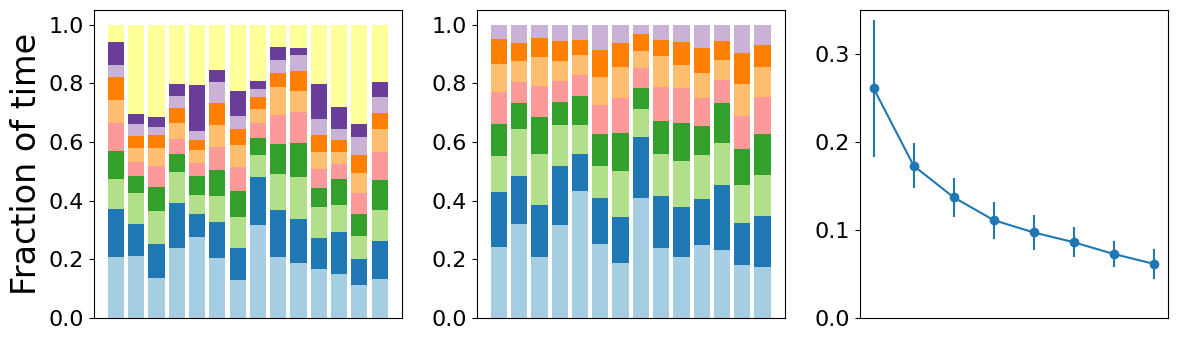

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

num_speaker, num_session = data.shape[0], data.shape[2]
x = np.arange(num_session)
bot = np.zeros((num_session,))


undetermined_time = data[:,3,:].sum(axis=0) - data[:,0,:].sum(axis=0)
silence_undetermined_time = np.array(total_end_time) - data[:,0,:].sum(axis=0) - np.array(intro_end_list) - np.array(dropped_time)
total_session_time = np.array(total_end_time) - np.array(intro_end_list) - np.array(dropped_time)

cmap = plt.cm.get_cmap('Paired', 11)
colors = cmap(range(11))

for i in range(num_speaker):
    axes[0].bar(x, data[i,0,:]/total_session_time, bottom=bot, color=colors[i])
    bot = bot + data[i,0,:]/total_session_time

#add silence and undetermined intervals
axes[0].bar(x, undetermined_time/total_session_time, bottom=bot, color=colors[num_speaker])
axes[0].bar(x, (silence_undetermined_time-undetermined_time)/total_session_time, bottom=bot+undetermined_time/total_session_time, color=colors[num_speaker+1])

box = axes[0].get_position()
axes[0].set_position([box.x0, box.y0, box.width * 0.8, box.height])

axes[0].set_ylabel("Fraction of time", fontsize=24)
axes[0].set_xticks([])
axes[0].tick_params(axis='y', labelsize=16)
axes[0].set_box_aspect(1)



total_session_time = data[:,0,:].sum(axis=0)

cmap = plt.cm.get_cmap('Paired', 11)
colors = cmap(range(9))
bot = np.zeros((num_session,))

for i in range(num_speaker):
    axes[1].bar(x, data[i,0,:]/total_session_time, bottom=bot, color=colors[i])
    bot = bot + data[i,0,:]/total_session_time

box = axes[1].get_position()
axes[1].set_position([box.x0, box.y0, box.width * 0.8, box.height])

axes[1].set_xticks([])
axes[1].tick_params(axis='y', labelsize=16)
axes[1].set_box_aspect(1)


axes[2].errorbar(np.arange(1,9), data_normalized.mean(axis=2)[:,0], yerr=data_normalized.std(axis=2)[:,0], fmt='-o')

box = axes[2].get_position()
axes[2].set_position([box.x0, box.y0, box.width * 0.8, box.height])

axes[2].set_xticks([])
axes[2].set_ylim([0,0.35])
axes[2].tick_params(axis='y', labelsize=16)
axes[2].tick_params(axis='x', labelsize=16)
axes[2].set_box_aspect(1)

for i, ax in enumerate(axes):
    # Add white space at top
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax)
    
    
fig.subplots_adjust(wspace=0.2)
plt.show()

## Visualize MBC2

In [11]:
#session without the require of namematch
session_list = ["MBC2_1_1", "MBC2_1_2", "MBC2_1_3","MBC2_2_1","MBC2_2_2","MBC2_2_3","MBC2_3_1","MBC2_3_2","MBC2_4_1","MBC2_4_2","MBC2_4_3","MBC2_5_1","MBC2_5_2","MBC2_5_3"]
num_speaker_list = [12,9,12,10,10,12,12,12,11,12,12,13,13,11]
start_list = [0,360,0,0,500,300,0,0,0,0,0,0,0,0]
intro_start_list = [0,0,439,70,699,300,270,119,0,93,263,198,199,101]
intro_end_list = [277,0,916,396,980,300,969,707,0,651,676,515,536,498]
intro_idx_list = [0,0,10,0,0,0,0,9,0,4,0,0,0,0]
window_list = [400,400,600,600,600,600,600,800,600,600,600,500,600,400]
given_idx_list = [1,5,1,5,2,2,4,0,4,1,2,8,12,1]
facillitator_list = [4,0,1,0,2,0,0,0,1,1,0,1,0,0]

In [12]:
df_list = []
total_end_time = []
for i in range(len(session_list)):
    conference = "MBC2"
    session = session_list[i]
    num_speaker = num_speaker_list[i]
    start = start_list[i]
    intro_start = intro_start_list[i]
    intro_end = intro_end_list[i]
    intro_idx = intro_idx_list[i]
    window = window_list[i]
    
    Pydia_test = Pydia(conference, session, num_speaker)
    #intros, intro, min_idx, d_list, flat, allspeaker, total_time, speakers = Pydia_test.select_Intro()
    intros, intro, min_idx, d_list, flat, allspeaker, total_time, speakers = Pydia_test.select_Intro(start=start,idx=intro_idx,window=window, given_idx=given_idx_list[i])
    #print(intros) #may need to choose intro from intros manually to improve performance
    
    total_end_time.append(flat[-1][1])
    
    confidence_test = Confidence(conference, session, num_speaker)
    confidence, confidence_matrix, r1_flat = confidence_test.Pyconf(allspeaker, total_time)

    analyzer_test = Analyzer(conference, session, num_speaker, flat, confidence)
    flat_clean = analyzer_test.clean_segment()
    tmp_total_time, tmp_total_turns, tmp_segments, tmp_time_hist = analyzer_test.stats_spk_time(START=intro_end)
    bf_total_time, bf_total_turns, bf_segments, bf_time_hist = analyzer_test.stats_spk_time_before_clean(START=intro_end)

    tmp_df = analyzer_test.get_stats()
    sort_by_time = tmp_df.sort_values('total_time', ascending=False)
    df_list.append(sort_by_time)
    #session_speaking_time = sort_by_time['total_time'].sum()

In [13]:
#exclude facillitator
df = df_list[0]

dropped_time = [df['total_time'][facillitator_list[0]]]

df = df.drop(facillitator_list[0])
df = df.reset_index(drop=True)
df = df[:8]
data = df.to_numpy()
data_normalized = data/data.sum(axis=0)
#data = data/data.sum(axis=0)
data = data[...,None]
data_normalized = data_normalized[...,None]
for i in range(1,len(df_list)):
    tmp_df = df_list[i]
    dropped_time.append(tmp_df['total_time'][facillitator_list[i]])
    tmp_df = tmp_df.drop(facillitator_list[i])
    tmp_df = tmp_df.reset_index(drop=True)
    tmp_df = tmp_df[:8]
    #df = pd.concat([df,pd.DataFrame({'total_time':self.total_time_bf[i], 'total_turns':self.total_turns_bf[i]},index=[i])])
    tmp_data = tmp_df.to_numpy()
    #tmp_data = tmp_data/tmp_data.sum(axis=0)
    tmp_data_normalized = tmp_data/tmp_data.sum(axis=0)
    data = np.concatenate([data, tmp_data[...,None]], axis=2)
    data_normalized = np.concatenate([data_normalized, tmp_data_normalized[...,None]], axis=2)
data = data.astype("float")
data_normalized = data_normalized.astype("float")

In [14]:
data_normalized.shape

(8, 6, 14)

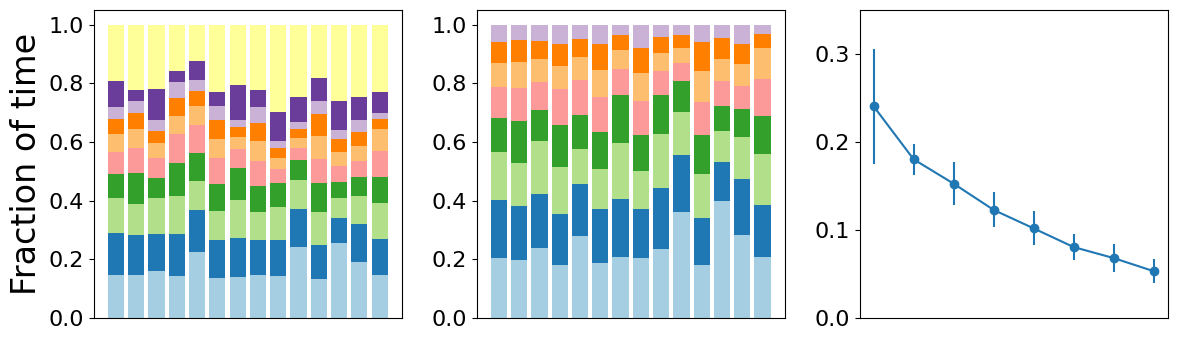

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

num_speaker, num_session = data.shape[0], data.shape[2]
x = np.arange(num_session)
bot = np.zeros((num_session,))


undetermined_time = data[:,3,:].sum(axis=0) - data[:,0,:].sum(axis=0)
silence_undetermined_time = np.array(total_end_time) - data[:,0,:].sum(axis=0) - np.array(intro_end_list) - np.array(dropped_time)
total_session_time = np.array(total_end_time) - np.array(intro_end_list) - np.array(dropped_time)

cmap = plt.cm.get_cmap('Paired', 11)
colors = cmap(range(11))

for i in range(num_speaker):
    axes[0].bar(x, data[i,0,:]/total_session_time, bottom=bot, color=colors[i])
    bot = bot + data[i,0,:]/total_session_time

#add silence and undetermined intervals
axes[0].bar(x, undetermined_time/total_session_time, bottom=bot, color=colors[num_speaker])
axes[0].bar(x, (silence_undetermined_time-undetermined_time)/total_session_time, bottom=bot+undetermined_time/total_session_time, color=colors[num_speaker+1])

box = axes[0].get_position()
axes[0].set_position([box.x0, box.y0, box.width * 0.8, box.height])

#axes[0].set_xlabel("Sessions", fontsize=24)
axes[0].set_ylabel("Fraction of time", fontsize=24)
#axes[0].tick_params(axis='x', labelsize=16)
axes[0].set_xticks([])
axes[0].tick_params(axis='y', labelsize=16)
axes[0].set_box_aspect(1)



total_session_time = data[:,0,:].sum(axis=0)

cmap = plt.cm.get_cmap('Paired', 11)
colors = cmap(range(9))
bot = np.zeros((num_session,))

for i in range(num_speaker):
    axes[1].bar(x, data[i,0,:]/total_session_time, bottom=bot, color=colors[i])
    bot = bot + data[i,0,:]/total_session_time

box = axes[1].get_position()
axes[1].set_position([box.x0, box.y0, box.width * 0.8, box.height])

#axes[1].set_xlabel("Sessions", fontsize=24)
axes[1].set_xticks([])
axes[1].tick_params(axis='y', labelsize=16)
axes[1].set_box_aspect(1)


axes[2].errorbar(np.arange(1,9), data_normalized.mean(axis=2)[:,0], yerr=data_normalized.std(axis=2)[:,0], fmt='-o')

box = axes[2].get_position()
axes[2].set_position([box.x0, box.y0, box.width * 0.8, box.height])

#axes[2].set_xlabel("Speaker rank", fontsize=24)
#axes[1].set_ylabel("Speaking time", fontsize=24)
#axes[1].tick_params(axis='x', labelsize=16)
#axes[2].set_xticks([1,2,3,4,5,6,7,8])
axes[2].set_xticks([])
axes[2].set_ylim([0,0.35])
axes[2].tick_params(axis='y', labelsize=16)
axes[2].tick_params(axis='x', labelsize=16)
axes[2].set_box_aspect(1)

for i, ax in enumerate(axes):
    # Add white space at top
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax)
    
    
fig.subplots_adjust(wspace=0.2)
plt.show()

## Visualize LSST1

In [16]:
session_list = ["LSST1_1_2","LSST1_1_3","LSST1_2_1","LSST1_2_2","LSST1_2_3","LSST1_3_1","LSST1_3_2","LSST1_3_3","LSST1_4_1","LSST1_4_2","LSST1_4_3","LSST1_5_2"]
num_speaker_list = [12,14,13,14,14,14,13,12,13,14,12,13]
start_list = [0,0,0,0,0,0,0,0,0,0,0,0]
intro_end_list = [252,180,361,448,300,546,523,886,420,418,720,547]
intro_start_list = [144,51,71,93,110,363,255,228,206,212,240,147]
intro_idx_list = [0,0,-1,-2,0,0,0,0,2,17,10,0]
window_list = [600,600,600,600,600,600,600,600,600,600,600,600]
given_idx_list = [5,-1,-1,-1,-1,4,4,0,-1,-1,7,5]
facillitator_list = [[3,5],[0],[2,3],[0,2],[0,3],[8,2],[1,3],[0,6],[1,2],[2,0],[3,0],[8,9]]

In [17]:
df_list = []
total_end_time = []
for i in range(len(session_list)):
    conference = "LSST1"
    session = session_list[i]
    num_speaker = num_speaker_list[i]
    start = start_list[i]
    intro_start = intro_start_list[i]
    intro_end = intro_end_list[i]
    intro_idx = intro_idx_list[i]
    window = window_list[i]
    given_idx = given_idx_list[i]
    
    Pydia_test = Pydia(conference, session, num_speaker)
    #intros, intro, min_idx, d_list, flat, allspeaker, total_time, speakers = Pydia_test.select_Intro()
    intros, intro, min_idx, d_list, flat, allspeaker, total_time, speakers = Pydia_test.select_Intro(start=start,idx=intro_idx,window=window,given_idx=given_idx)
    #print(intros) #may need to choose intro from intros manually to improve performance
    
    total_end_time.append(flat[-1][1])
    
    confidence_test = Confidence(conference, session, num_speaker)
    confidence, confidence_matrix, r1_flat = confidence_test.Pyconf(allspeaker, total_time)

    analyzer_test = Analyzer(conference, session, num_speaker, flat, confidence)
    flat_clean = analyzer_test.clean_segment()
    tmp_total_time, tmp_total_turns, tmp_segments, tmp_time_hist = analyzer_test.stats_spk_time(START=intro_start)
    bf_total_time, bf_total_turns, bf_segments, bf_time_hist = analyzer_test.stats_spk_time_before_clean(START=intro_start)

    tmp_df = analyzer_test.get_stats()
    sort_by_time = tmp_df.sort_values('total_time', ascending=False)
    df_list.append(sort_by_time)
    #session_speaking_time = sort_by_time['total_time'].sum()

In [18]:
#exclude facillitator
df = df_list[0]

dropped_time = [df['total_time'][facillitator_list[0]].sum()]

df = df.drop(facillitator_list[0])
df = df.reset_index(drop=True)
df = df[:8]
data = df.to_numpy()
data_normalized = data/data.sum(axis=0)
#data = data/data.sum(axis=0)
data = data[...,None]
data_normalized = data_normalized[...,None]
for i in range(1,len(df_list)):
    tmp_df = df_list[i]
    dropped_time.append(tmp_df['total_time'][facillitator_list[i]].sum())
    tmp_df = tmp_df.drop(facillitator_list[i])
    tmp_df = tmp_df.reset_index(drop=True)
    tmp_df = tmp_df[:8]
    #df = pd.concat([df,pd.DataFrame({'total_time':self.total_time_bf[i], 'total_turns':self.total_turns_bf[i]},index=[i])])
    tmp_data = tmp_df.to_numpy()
    #tmp_data = tmp_data/tmp_data.sum(axis=0)
    tmp_data_normalized = tmp_data/tmp_data.sum(axis=0)
    data = np.concatenate([data, tmp_data[...,None]], axis=2)
    data_normalized = np.concatenate([data_normalized, tmp_data_normalized[...,None]], axis=2)
data = data.astype("float")
data_normalized = data_normalized.astype("float")

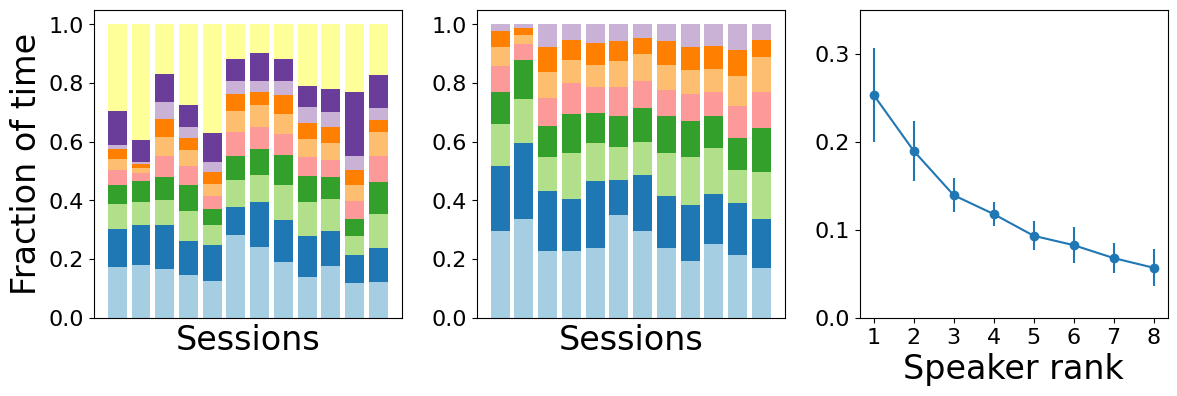

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

num_speaker, num_session = data.shape[0], data.shape[2]
x = np.arange(num_session)
bot = np.zeros((num_session,))


undetermined_time = data[:,3,:].sum(axis=0) - data[:,0,:].sum(axis=0)
total_end_time_new = [4000]*len(total_end_time)
total_end_time_new[7] = total_end_time[7]

silence_undetermined_time = np.array(total_end_time_new) - data[:,0,:].sum(axis=0) - np.array(intro_end_list) - np.array(dropped_time)
total_session_time = np.array(total_end_time_new) - np.array(intro_end_list) - np.array(dropped_time)

cmap = plt.cm.get_cmap('Paired', 11)
colors = cmap(range(11))

for i in range(num_speaker):
    axes[0].bar(x, data[i,0,:]/total_session_time, bottom=bot, color=colors[i])
    bot = bot + data[i,0,:]/total_session_time

#add silence and undetermined intervals
axes[0].bar(x, undetermined_time/total_session_time, bottom=bot, color=colors[num_speaker])
axes[0].bar(x, (silence_undetermined_time-undetermined_time)/total_session_time, bottom=bot+undetermined_time/total_session_time, color=colors[num_speaker+1])

box = axes[0].get_position()
axes[0].set_position([box.x0, box.y0, box.width * 0.8, box.height])

axes[0].set_xlabel("Sessions", fontsize=24)
axes[0].set_ylabel("Fraction of time", fontsize=24)
#axes[0].tick_params(axis='x', labelsize=16)
axes[0].set_xticks([])
axes[0].tick_params(axis='y', labelsize=16)
axes[0].set_box_aspect(1)



total_session_time = data[:,0,:].sum(axis=0)

cmap = plt.cm.get_cmap('Paired', 11)
colors = cmap(range(9))
bot = np.zeros((num_session,))

for i in range(num_speaker):
    axes[1].bar(x, data[i,0,:]/total_session_time, bottom=bot, color=colors[i])
    bot = bot + data[i,0,:]/total_session_time

box = axes[1].get_position()
axes[1].set_position([box.x0, box.y0, box.width * 0.8, box.height])

axes[1].set_xlabel("Sessions", fontsize=24)
axes[1].set_xticks([])
axes[1].tick_params(axis='y', labelsize=16)
axes[1].set_box_aspect(1)


axes[2].errorbar(np.arange(1,9), data_normalized.mean(axis=2)[:,0], yerr=data_normalized.std(axis=2)[:,0], fmt='-o')

box = axes[2].get_position()
axes[2].set_position([box.x0, box.y0, box.width * 0.8, box.height])

axes[2].set_xlabel("Speaker rank", fontsize=24)
axes[2].set_xticks([1,2,3,4,5,6,7,8])
axes[2].set_ylim([0,0.35])
axes[2].tick_params(axis='y', labelsize=16)
axes[2].tick_params(axis='x', labelsize=16)
axes[2].set_box_aspect(1)

panel_labels = ['g', 'h', 'i']
for i, ax in enumerate(axes):
    # Add white space at top
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax)
    
fig.subplots_adjust(wspace=0.2)
plt.show()